# 08 · Adaptive Sampling — Putting Collocation Points Where They Matter

**Level:** Advanced
**Prerequisites:** `04_burgers_equation`

Uniform random collocation wastes capacity: it spends as many points on smooth,
easy regions as on sharp layers where the residual is huge. **Residual-based
Adaptive Refinement (RAR)** fixes this — periodically evaluate the PDE residual
on a dense candidate set and *add* new collocation points where the residual is
largest. It is one of the highest-value, lowest-effort PINN upgrades.

### What you will learn
1. Implementing RAR (Lu et al. 2021, DeepXDE)
2. A problem with a thin **boundary layer** that punishes uniform sampling
3. Measuring the accuracy gain from adaptivity

### References
- Lu et al. (2021), *DeepXDE*, SIAM Review 63(1):208-228 (RAR is introduced here)
- Wu et al. (2023), *A comprehensive study of non-adaptive and residual-based adaptive sampling for PINNs*, CMAME


## 1 · A stiff steady problem

Steady 1-D advection–diffusion:

$$\frac{du}{dx} = \varepsilon\,\frac{d^2u}{dx^2},
\qquad u(0)=0,\; u(1)=1,\qquad \varepsilon=0.05.$$

Exact solution:

$$u(x)=\frac{e^{x/\varepsilon}-1}{e^{1/\varepsilon}-1}.$$

For small $\varepsilon$ the solution is nearly zero across most of the domain and
then rises steeply in a **boundary layer** of width $\sim\varepsilon$ near $x=1$.
Uniform sampling barely places points in that layer.


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eps = 0.05
def exact(x):
    return (np.exp(x/eps)-1)/(np.exp(1/eps)-1)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,50), nn.Tanh(),
                                 nn.Linear(50,50), nn.Tanh(),
                                 nn.Linear(50,50), nn.Tanh(), nn.Linear(50,1))
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x): return self.net(x)

def residual(model, x):
    u = model(x)
    ux = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    uxx= torch.autograd.grad(ux, x, torch.ones_like(ux), create_graph=True)[0]
    return ux - eps*uxx


In [2]:
def train(model, x_col, epochs=4000):
    xb = torch.tensor([[0.0],[1.0]], device=device)
    ub = torch.tensor([[0.0],[1.0]], device=device)
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    for ep in range(epochs):
        opt.zero_grad()
        r = residual(model, x_col)
        loss = torch.mean(r**2) + 50*torch.mean((model(xb)-ub)**2)
        loss.backward(); opt.step()
    return model

def rel_error(model):
    xs = np.linspace(0,1,1000)
    xt = torch.tensor(xs, dtype=torch.float32, device=device).view(-1,1)
    with torch.no_grad():
        up = model(xt).cpu().numpy().ravel()
    ue = exact(xs)
    return np.linalg.norm(up-ue)/np.linalg.norm(ue), xs, up, ue


In [3]:
# --- Baseline: uniform collocation ---
N0 = 60
x_uni = torch.rand(N0,1,device=device, requires_grad=True)
m_uni = train(Net().to(device), x_uni, epochs=4000)
e_uni, xs, up_uni, ue = rel_error(m_uni)
print(f"[uniform]  {N0} points -> rel L2 = {e_uni:.3e}")


[uniform]  60 points -> rel L2 = 2.711e+00


In [4]:
# --- RAR: start small, add points where residual is largest ---
x_rar = torch.rand(20,1,device=device, requires_grad=True)
model = Net().to(device)
n_rounds, add_per_round = 8, 5
for rnd in range(n_rounds):
    model = train(model, x_rar, epochs=1500)
    # evaluate residual on dense candidate pool
    cand = torch.rand(5000,1,device=device, requires_grad=True)
    r = residual(model, cand).abs().detach().cpu().numpy().ravel()
    idx = np.argsort(r)[-add_per_round:]         # worst offenders
    new_pts = cand[idx].detach()
    x_rar = torch.cat([x_rar.detach(), new_pts]).requires_grad_(True)
e_rar, _, up_rar, _ = rel_error(model)
print(f"[RAR]      {x_rar.shape[0]} points -> rel L2 = {e_rar:.3e}")
print(f"points landing in the layer (x>0.8): {(x_rar.detach().cpu().numpy()>0.8).mean()*100:.0f}%")


[RAR]      60 points -> rel L2 = 6.525e-03
points landing in the layer (x>0.8): 52%


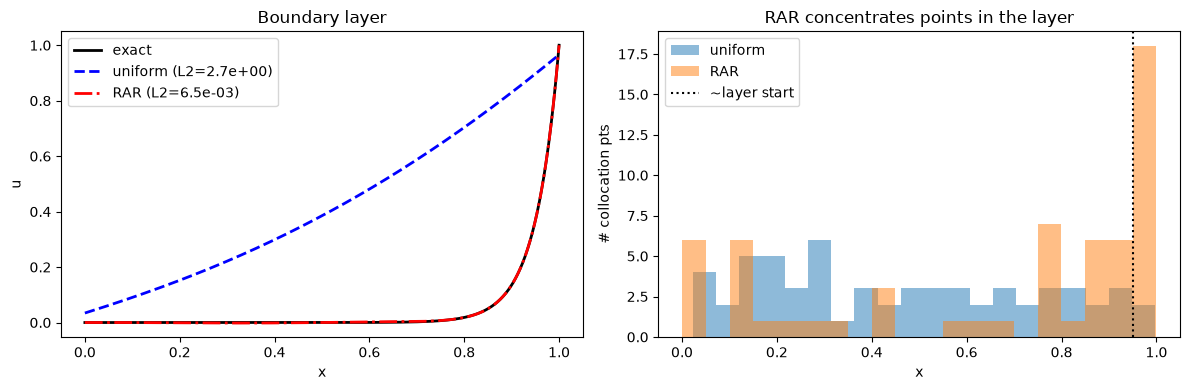

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(xs, ue, 'k-', lw=2, label='exact')
ax[0].plot(xs, up_uni, 'b--', lw=2, label=f'uniform (L2={e_uni:.1e})')
ax[0].plot(xs, up_rar, 'r-.', lw=2, label=f'RAR (L2={e_rar:.1e})')
ax[0].set_xlabel('x'); ax[0].set_ylabel('u'); ax[0].legend(); ax[0].set_title('Boundary layer')

ax[1].hist(x_uni.detach().cpu().numpy().ravel(), bins=20, alpha=0.5, label='uniform')
ax[1].hist(x_rar.detach().cpu().numpy().ravel(), bins=20, alpha=0.5, label='RAR')
ax[1].axvline(1-eps, color='k', ls=':', label='~layer start')
ax[1].set_xlabel('x'); ax[1].set_ylabel('# collocation pts'); ax[1].legend()
ax[1].set_title('RAR concentrates points in the layer')
plt.tight_layout(); plt.show()


## 2 · Takeaways

- RAR typically matches or beats uniform sampling **with far fewer points**,
  because it spends its budget where the equation is hardest to satisfy.
- The core loop is tiny: *train a bit → score residual on a dense pool → append
  the worst points → repeat.*
- Variants: RAD (resample proportional to residual), RAR-D (density-based),
  gradient-based refinement. Wu et al. (2023) benchmarks them systematically.